# Jaguar Re-ID — MLP

**Architecture** : Flatten → Dense(256, relu) → Dense(128, relu) → Dense(31, softmax)  
**Improvement over Baseline** : None

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

2026-04-08 13:04:43.712809: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 13:04:53.349062: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-08 13:04:53.349092: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-04-08 13:04:53.404435: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 13:04:54.911801: W tensorflow/stream_executor/pla

TensorFlow: 2.10.0
GPU: []


2026-04-08 13:05:01.158091: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-08 13:05:01.158221: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-04-08 13:05:01.158314: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-04-08 13:05:01.158403: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcufft.so.10'; dlerror: libcufft.so.10: cannot open shared object file: No such file or directory
2026-04-08 13:05:01.158491: W tensorflow/stream_executor/platform/default/dso_loader.cc:64

In [ ]:
MODEL_NAME   = 'mlp_baseline'
AUGMENTATION = 'none'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

2026-04-08 13:05:08.465731: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [4]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "mlp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 150528)            0         
                                                                 
 dense (Dense)               (None, 256)               38535424  
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 31)                3999      
                                                                 
Total params: 38,572,319
Trainable params: 38,572,319
Non-trainable params: 0
_________________________________________________________________


## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (mlp) ===
  lr_0.01: val_acc=0.0950 (best epoch=20)
  lr_0.001: val_acc=0.6807 (best epoch=33)
  lr_0.0001: val_acc=0.6438 (best epoch=32)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.680739,33
1,lr_0.0001,0.643799,32
2,lr_0.01,0.094987,20



Best: lr_0.001 → val_acc=0.6807


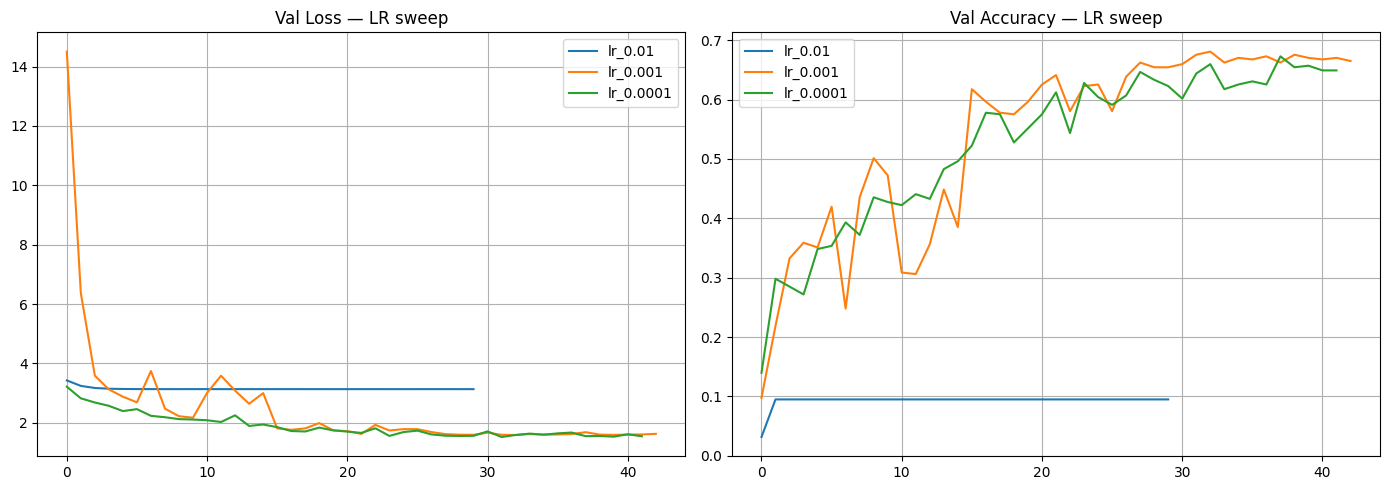

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100
48/48 [==============================] - 8s 149ms/step - loss: 67.1653 - accuracy: 0.0653 - val_loss: 16.5236 - val_accuracy: 0.1108 - lr: 0.0010
Epoch 2/100
48/48 [==============================] - 7s 143ms/step - loss: 7.1168 - accuracy: 0.2012 - val_loss: 4.7737 - val_accuracy: 0.2507 - lr: 0.0010
Epoch 3/100
48/48 [==============================] - 7s 144ms/step - loss: 3.1133 - accuracy: 0.3285 - val_loss: 4.4505 - val_accuracy: 0.2375 - lr: 0.0010
Epoch 4/100
48/48 [==============================] - 7s 143ms/step - loss: 2.8736 - accuracy: 0.3417 - val_loss: 3.1000 - val_accuracy: 0.2797 - lr: 0.0010
Epoch 5/100
48/48 [==============================] - 7s 145ms/step - loss: 2.3121 - accuracy: 0.3892 - val_loss: 2.8343 - val_accuracy: 0.3615 - lr: 0.0010
Epoch 6/100
48/48 [==============================] - 7s 138ms/step - loss: 2.0592 - accuracy: 0.4743 - val_loss: 3.3396 - val_accuracy: 0.3272 - lr: 0.0010
Epoch 7/100
48/48 [==============================] - 7s 140ms/

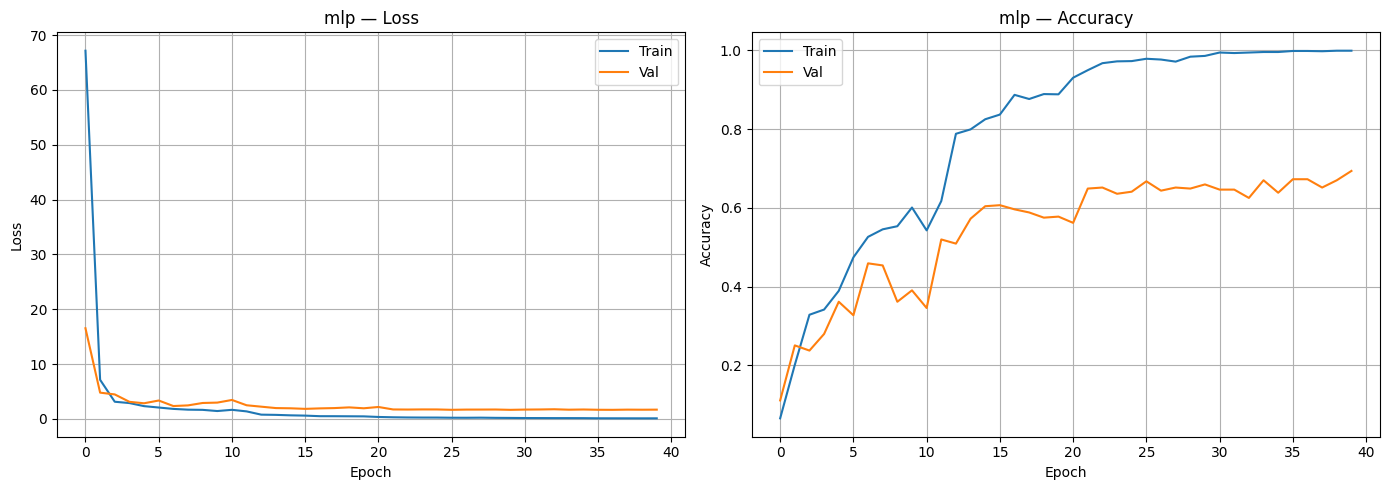

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

mlp (best LR=0.001):
  Train — Loss: 0.1284, Acc: 0.9947
  Val   — Loss: 1.6381, Acc: 0.6596


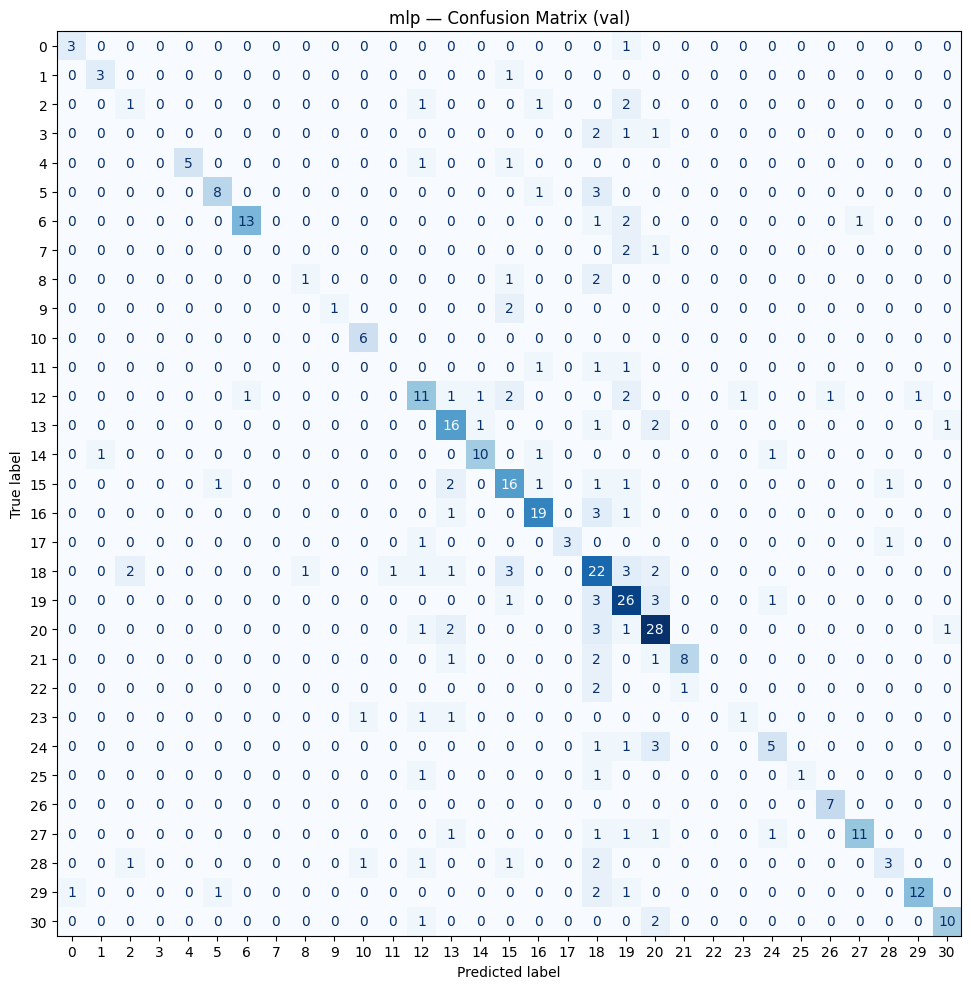

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 33 epochs
Epoch 1/33
60/60 [==============================] - 5s 71ms/step - loss: 54.0069 - accuracy: 0.0860
Epoch 2/33
60/60 [==============================] - 4s 69ms/step - loss: 6.2693 - accuracy: 0.2032
Epoch 3/33
60/60 [==============================] - 4s 71ms/step - loss: 3.6556 - accuracy: 0.2443
Epoch 4/33
60/60 [==============================] - 4s 69ms/step - loss: 2.9922 - accuracy: 0.3193
Epoch 5/33
60/60 [==============================] - 4s 71ms/step - loss: 2.2148 - accuracy: 0.4332
Epoch 6/33
60/60 [==============================] - 4s 71ms/step - loss: 2.1210 - accuracy: 0.4485
Epoch 7/33
60/60 [==============================] - 4s 69ms/step - loss: 1.9990 - accuracy: 0.4792
Epoch 8/33
60/60 [==============================] - 4s 70ms/step - loss: 2.0491 - accuracy: 0.4607
Epoch 9/33
60/60 [==============================] - 4s 74ms/step - loss: 1.6752 - accuracy: 0.5472
Epoch 10/33
60/60 [==============================] - 

In [14]:
inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 [==============================] - 0s 16ms/step
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_mlp.csv


,row_id,similarity
0,0,0.856893
1,1,0.853913
2,2,0.633241
3,3,0.753133
4,4,0.797562


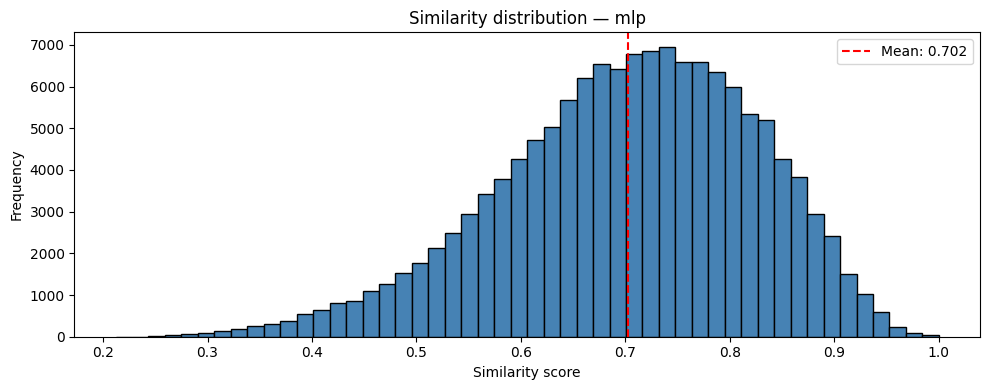

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Metrique | Train | Val |
|----------|-------|-----|
| Accuracy | 0.9947 | 0.6596 |
| Loss     | 0.1284 | 1.6381 |
| Overfitting ? | — | Oui (fort) |
| Kaggle Score (public) | — | 0.164 |
| Kaggle Score (private) | — | 0.178 |

### Analyse des hyperparamètres

**Hyperparamètres du modèle :**

- **Structure (Flatten → Dense(256) → Dense(128) → Dense(31))** : On ajoute 2 couches cachées par rapport au linéaire pour introduire de la non-linéarité. Mais le Flatten est toujours en entrée : le MLP travaille sur le même vecteur de 150 528 pixels bruts, sans aucune notion de voisinage spatial. Résultat : 38.5M de paramètres (8x le linéaire), dont 38.5M dans la première Dense seule (150 528 × 256). Cette couche massive est la raison principale de l'overfitting — c'est une matrice géante qui peut mémoriser chaque image individuellement.

- **Fonctions d'activation (relu + softmax)** : Les ReLU dans les couches cachées permettent au modèle de capturer des relations non-linéaires entre pixels, contrairement au linéaire. En théorie, cela devrait améliorer les performances. En pratique, la val_acc baisse de 73.1% (linéaire) à 65.9% (MLP). La non-linéarité ne compense pas la sur-paramétrisation : le modèle a tellement de capacité qu'il mémorise le train set au lieu d'apprendre des patterns généralisables.

- **Data augmentation (none)** : Même justification que le linéaire — le modèle travaille sur des pixels flattened, l'augmentation spatiale (flip, rotation) déplacerait les pixels à des positions différentes dans le vecteur 150k. Sans convolutions, l'augmentation est contre-productive.

**Paramètres d'apprentissage :**

- **Learning rate (sweep : 0.01, 0.001, 0.0001)** : Le LR est le paramètre le plus critique du MLP. lr=0.01 collapse complètement à 9.5% (≈ hasard sur 31 classes), car les gradients sont trop grands pour la première couche Dense(256) qui a 38.5M de poids — les mises à jour déstabilisent les poids. lr=0.001 (68.1%) surpasse lr=0.0001 (64.4%) qui converge trop lentement. Contrairement au linéaire où les 3 LR donnaient ~72%, ici le LR fait varier les résultats de 9.5% à 68% — preuve que la profondeur rend le modèle sensible au LR.

- **Optimizer (Adam)** : Adam est crucial pour le MLP. Son momentum adaptatif aide à naviguer la surface de loss plus complexe qu'un modèle linéaire. Les réductions de LR via ReduceLR (0.001 → 0.0005 → 0.00025 → 0.000125) montrent que le modèle a besoin de ralentir progressivement pour se stabiliser — signe qu'il oscille autour d'un minimum plutôt que d'y converger proprement.

- **Batch size (32)** : Même valeur que le linéaire. Avec 38.5M de paramètres, un batch plus grand (64, 128) pourrait donner des gradients plus stables, mais augmenterait la consommation mémoire déjà élevée.

- **EarlyStopping (patience=10) et ReduceLROnPlateau (patience=5, factor=0.5)** : L'EarlyStopping arrête le training à l'epoch ~40. Le ReduceLR intervient 3 fois (epochs 12, 21, 35, 40), divisant le LR par 16 au total. À chaque réduction, on observe un saut de performance temporaire (ex: epoch 22-23 après réduction), mais le modèle retombe vite en overfitting. Cela montre que le LR scheduling ne peut pas compenser le manque de régularisation structurelle.

**Overfitting :**

Gap train/val de ~33 points (99.5% vs 65.9%), pire que le linéaire (~27 pts). Le ratio paramètres/données est encore plus extrême : 38.5M / 1516 ≈ 25 000 params/image (vs 3000 pour le linéaire). La val_loss (1.64) est meilleure que le linéaire (8.38) en valeur absolue, mais la val_accuracy est inférieure. Cela s'explique par la sortie softmax : le linéaire produit des prédictions plus "confiantes" (plus fausses quand il se trompe), d'où une loss élevée mais une accuracy plus haute.

### Verdict

- [x] Dead-end : Le MLP sur pixels flattened est une impasse. Ajouter de la capacité (couches cachées) sans notion spatiale dégrade les performances au lieu de les améliorer. On pourrait ajouter du Dropout ou du weight decay pour réduire l'overfitting, mais cela ramènerait au mieux au niveau du linéaire sans le dépasser. Le problème fondamental n'est pas le manque de capacité — c'est l'absence de structure spatiale dans la représentation d'entrée.

### Interprétation

Le MLP confirme un enseignement clé : la capacité du modèle ne compense pas une mauvaise représentation des données. Le linéaire avec 4.6M params surpasse le MLP avec 38.5M, prouvant que le Flatten détruit l'information spatiale nécessaire à la tâche. Les embeddings passent de 150k dims (linéaire) à 128 dims (MLP), ce qui est plus compact, mais le score Kaggle reste identique (0.164 vs 0.165). La compression ne rend pas les features plus discriminantes. Pour progresser, il faut changer fondamentalement l'entrée du réseau : conserver la structure 2D des images avec des convolutions qui peuvent apprendre des patterns visuels (taches, contours, textures) au lieu de corrélations pixel-à-pixel.